In [118]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, softmax
from sklearn.preprocessing import RobustScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [119]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
time_col = 'ENGINE_RUN_TINE ()'

files = [file for file in os.listdir(path) if file.endswith('.csv')]

df_list = []
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(f'{path}/{file}', index_col=False)
        df['drive_id'] = file
        df_list.append(df)


print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


# %%
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
    """
    Compute std of each std-computable column (numeric only)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
  
    print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
    if len(zero_variance_cols) > 0:
        df = df.drop(columns=zero_variance_cols)
  
    return df


# %%
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, time_col: str, id_cols: list[str] = None) -> pd.DataFrame:
    """
    Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
    This preserves the overall statistics while removing duplicate entries.
    
    Note: The time column itself is not averaged (it becomes the group key).
    Only numeric columns are averaged when multiple rows share the same timestamp.
    """
    if id_cols is None:
        id_cols = []
    
    existing_id_cols = [col for col in id_cols if col in df.columns]
    
    group_cols = [time_col] + existing_id_cols
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
  
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
    return df_clean


# %%
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


# %%
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)


# %%
# Combine all dataframes
data = pd.concat(df_list, ignore_index=True)


# Clean up
print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")


# remove some useless columns
data = data.drop(columns=['WARM_UPS_SINCE_CODES_CLEARED ()', 'TIME_SINCE_TROUBLE_CODES_CLEARED ()'])


data = mean_fill_missing_timestamps_and_remove_duplicates(data, time_col=time_col, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col=time_col,
    source_file_col='drive_id',
    downsample_factor=1
)
data.drop(columns=["drive_id"], inplace=True)


129 files loaded out of 129
Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']


In [120]:
train_ratio = 0.7
val_ratio = 0.15

train_size = int(len(data) * train_ratio)
val_size = int(len(data) * val_ratio)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

scaler = RobustScaler()
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

train_data_scaled = np.clip(train_data_scaled, -10, 10)
val_data_scaled = np.clip(val_data_scaled, -10, 10)  
test_data_scaled = np.clip(test_data_scaled, -10, 10)

print(f"Train: {train_data_scaled.shape}")
print(f"Val: {val_data_scaled.shape}")
print(f"Test: {test_data_scaled.shape}")

def create_sliding_windows(data, window_size=5):
    """
    Create sliding windows for time series
    X: [num_samples, num_features, window_size] - input windows
    y: [num_samples, num_features] - target values (next timestep)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size].T)  # [num_features, window_size]
        y.append(data[i+window_size])      # [num_features]
    return np.array(X), np.array(y)

window_size = 5
X_train, y_train = create_sliding_windows(train_data_scaled, window_size)
X_val, y_val = create_sliding_windows(val_data_scaled, window_size)
X_test, y_test = create_sliding_windows(test_data_scaled, window_size)

print(f"X_train shape: {X_train.shape}")  # [samples, num_features, window_size]
print(f"y_train shape: {y_train.shape}")  # [samples, num_features]

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Train: (57684, 22)
Val: (12361, 22)
Test: (12362, 22)
X_train shape: (57679, 22, 5)
y_train shape: (57679, 22)
Number of training batches: 902
Number of validation batches: 194
Number of test batches: 194


In [121]:
class GraphAttentionLayer(MessagePassing):
    """
    Numerically stable Graph Attention Layer
    """
    def __init__(self, in_dim, out_dim, embed_dim):
        super().__init__(aggr='add')
        
        # Feature transformation
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        
        # Attention mechanism
        self.att = nn.Linear(2 * (embed_dim + out_dim), 1, bias=False)
        
        self.embed_dim = embed_dim
        self.out_dim = out_dim
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        # ✅ CRITICAL: Initialize weights properly
        nn.init.xavier_normal_(self.W.weight, gain=0.1)
        nn.init.xavier_normal_(self.att.weight, gain=0.1)
    
    def forward(self, x, edge_index, embeddings):
        """
        x: [num_nodes, in_dim]
        edge_index: [2, num_edges]
        embeddings: [num_nodes, embed_dim]
        """
        # ✅ Check for NaN in inputs
        if torch.isnan(x).any():
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)
        
        if torch.isnan(embeddings).any():
            embeddings = torch.nan_to_num(embeddings, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Transform features
        x_transformed = self.W(x)
        
        # ✅ Check after transformation
        if torch.isnan(x_transformed).any():
            x_transformed = torch.nan_to_num(x_transformed, nan=0.0)
        
        # Concatenate with embeddings
        x_with_embed = torch.cat([embeddings, x_transformed], dim=1)
        
        # Message passing
        out = self.propagate(edge_index, x=x_with_embed, size=None)
        
        return F.relu(out)
    
    def message(self, x_i, x_j, edge_index_i, size_i):
        """
        ✅ FIXED: Added size_i parameter (critical for batched graphs!)
        """
        # Concatenate source and target
        x_cat = torch.cat([x_i, x_j], dim=-1)
        
        # Clamp to prevent extreme values
        x_cat = torch.clamp(x_cat, min=-5.0, max=5.0)  # ✅ Reduced from 10
        
        # Compute attention score
        alpha = self.att(x_cat)
        alpha = self.leaky_relu(alpha)
        
        # ✅ Clamp more aggressively
        alpha = torch.clamp(alpha, min=-5.0, max=5.0)
        
        # ✅ CRITICAL FIX: Pass size_i to softmax for batched graphs
        alpha = softmax(alpha, edge_index_i, num_nodes=size_i)
        
        # ✅ Add epsilon to prevent zero division
        alpha = alpha + 1e-8
        
        # ✅ Check for NaN after softmax
        if torch.isnan(alpha).any() or torch.isinf(alpha).any():
            alpha = torch.nan_to_num(alpha, nan=1e-8, posinf=1.0, neginf=0.0)
        
        # Get features and clamp
        x_j_features = x_j[:, -self.out_dim:]
        x_j_features = torch.clamp(x_j_features, min=-5.0, max=5.0)
        
        # Weighted message
        message = alpha * x_j_features
        
        # ✅ Final NaN check
        if torch.isnan(message).any():
            message = torch.nan_to_num(message, nan=0.0)
        
        return message


In [122]:
class GDN(nn.Module):
    def __init__(self, num_features, window_size, hidden_dim=64, embed_dim=64, topk=15):
        super().__init__()
        
        self.num_features = num_features
        self.window_size = window_size
        self.hidden_dim = hidden_dim
        self.embed_dim = embed_dim
        self.topk = min(topk, num_features - 1)
        
        # ✅ Smaller initialization
        self.embeddings = nn.Parameter(torch.randn(num_features, embed_dim) * 0.01)
        
        self.gat1 = GraphAttentionLayer(window_size, hidden_dim, embed_dim)
        self.gat2 = GraphAttentionLayer(hidden_dim, hidden_dim, embed_dim)
        
        self.fc = nn.Linear(hidden_dim, 1)
        
        # ✅ Initialize fc layer
        nn.init.xavier_normal_(self.fc.weight, gain=0.1)
        nn.init.constant_(self.fc.bias, 0)
        
        self.dropout = nn.Dropout(0.2)
        
        self.register_buffer('edge_index', None)
        self._edge_cache = {}
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Custom weight initialization"""
        if isinstance(module, nn.Linear):
            # Use smaller gain and ensure weights are not too large
            nn.init.xavier_normal_(module.weight, gain=0.1)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Parameter):
            # Ensure embeddings are small
            if module.data.size(0) == self.num_features:
                nn.init.normal_(module.data, mean=0.0, std=0.01)
    
    def learn_graph_structure(self):
        """Learn graph structure from embeddings"""
        # Ensure embeddings are not NaN or Inf
        if torch.isnan(self.embeddings).any() or torch.isinf(self.embeddings).any():
            print("Warning: Embeddings contain NaN/Inf, reinitializing...")
            nn.init.normal_(self.embeddings, mean=0.0, std=0.01)
        
        # Safe normalization: handle zero-norm vectors
        norms = torch.norm(self.embeddings, p=2, dim=1, keepdim=True)
        norms = torch.clamp(norms, min=1e-8)  # Prevent division by zero
        embeddings_norm = self.embeddings / norms
        
        # Check for NaN after normalization
        if torch.isnan(embeddings_norm).any():
            print("Warning: Normalized embeddings contain NaN, using identity")
            embeddings_norm = torch.eye(self.num_features, device=self.embeddings.device) * 0.01
        
        similarity = torch.mm(embeddings_norm, embeddings_norm.t())
        
        # Clamp similarity to valid range
        similarity = torch.clamp(similarity, min=-1.0, max=1.0)
        
        # Check for NaN in similarity
        if torch.isnan(similarity).any():
            print("Warning: Similarity matrix contains NaN, using identity")
            similarity = torch.eye(self.num_features, device=self.embeddings.device)
        
        similarity.fill_diagonal_(-1e9)
        
        _, topk_indices = torch.topk(similarity, self.topk, dim=1)
        
        edge_list = []
        for i in range(self.num_features):
            for j in topk_indices[i]:
                edge_list.append([j.item(), i])
        
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        
        # Validate edge_index
        if edge_index.size(0) != 2 or edge_index.size(1) == 0:
            raise ValueError(f"Invalid edge_index: {edge_index.shape}")
        
        return edge_index
    
    def get_batched_edge_index(self, batch_size, device):
        """Get or create cached batched edge index"""
        cache_key = (batch_size, str(device))
        if cache_key in self._edge_cache:
            return self._edge_cache[cache_key]
        
        offsets = torch.arange(batch_size, device=device) * self.num_features
        offsets = offsets.view(1, batch_size, 1)
        
        edge_index_batched = self.edge_index.unsqueeze(1) + offsets
        edge_index_batched = edge_index_batched.reshape(2, -1)
        
        self._edge_cache[cache_key] = edge_index_batched
        return edge_index_batched
    
    def forward(self, x):
        """
        x: [batch_size, num_features, window_size]
        """
        batch_size = x.size(0)
        device = x.device
        
        if self.edge_index is None:
            self.edge_index = self.learn_graph_structure().to(device)
        
        x_flat = x.reshape(batch_size * self.num_features, self.window_size)
        batch_embeddings = self.embeddings.repeat(batch_size, 1)
        
        edge_index_batch = self.get_batched_edge_index(batch_size, device)
        
        # Graph layers with checks
        h1 = self.gat1(x_flat, edge_index_batch, batch_embeddings)
        h1 = self.dropout(h1)
        
        h2 = self.gat2(h1, edge_index_batch, batch_embeddings)
        
        # Element-wise multiplication with embeddings (only if dimensions match)
        # Use embedding projection if needed
        if batch_embeddings.size(1) >= self.hidden_dim:
            h2 = h2 * batch_embeddings[:, :self.hidden_dim]
        else:
            # If embedding dim is smaller, pad or use a projection
            embed_proj = batch_embeddings[:, :min(self.hidden_dim, batch_embeddings.size(1))]
            if embed_proj.size(1) < self.hidden_dim:
                # Pad with ones if needed
                padding = torch.ones(batch_embeddings.size(0), self.hidden_dim - embed_proj.size(1), 
                                   device=batch_embeddings.device)
                embed_proj = torch.cat([embed_proj, padding], dim=1)
            h2 = h2 * embed_proj
        
        forecast = self.fc(h2).squeeze(-1)
        forecast = forecast.reshape(batch_size, self.num_features)
        
        # Clamp output to prevent extreme values
        forecast = torch.clamp(forecast, min=-10.0, max=10.0)
        
        return forecast


In [124]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


num_features = X_train.shape[1]
model = GDN(
    num_features=num_features,
    window_size=window_size,
    hidden_dim=64,
    embed_dim=64,
    topk=10
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001,
    betas=(0.9, 0.99),
    weight_decay=0.0001
)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)
criterion = nn.MSELoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            
            total_loss += loss.item()
    
    return total_loss / len(val_loader)


Using device: mps
Model parameters: 6,401


In [125]:
# Diagnostic: Check for NaN/inf in data and model outputs
print("=== Data Diagnostics ===")
print(f"X_train contains NaN: {np.isnan(X_train).any()}")
print(f"X_train contains Inf: {np.isinf(X_train).any()}")
print(f"y_train contains NaN: {np.isnan(y_train).any()}")
print(f"y_train contains Inf: {np.isinf(y_train).any()}")
print(f"X_train min/max: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"y_train min/max: [{y_train.min():.4f}, {y_train.max():.4f}]")

print("\n=== Model Diagnostics ===")
# Test forward pass with a single batch
model.eval()
with torch.no_grad():
    sample_X = X_train_tensor[:1].to(device)
    sample_y = y_train_tensor[:1].to(device)
    
    print(f"Sample input shape: {sample_X.shape}")
    print(f"Sample input min/max: [{sample_X.min():.4f}, {sample_X.max():.4f}]")
    
    try:
        y_pred = model(sample_X)
        print(f"Output shape: {y_pred.shape}")
        print(f"Output min/max: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
        print(f"Output contains NaN: {torch.isnan(y_pred).any()}")
        print(f"Output contains Inf: {torch.isinf(y_pred).any()}")
        
        loss = criterion(y_pred, sample_y)
        print(f"Loss value: {loss.item():.6f}")
        print(f"Loss is NaN: {torch.isnan(loss)}")
    except Exception as e:
        print(f"ERROR in forward pass: {e}")
        import traceback
        traceback.print_exc()

# Check model parameters
print("\n=== Parameter Diagnostics ===")
for name, param in model.named_parameters():
    if torch.isnan(param).any():
        print(f"NaN in {name}")
    if torch.isinf(param).any():
        print(f"Inf in {name}")
    print(f"{name}: min={param.min().item():.6f}, max={param.max().item():.6f}, mean={param.mean().item():.6f}")

# Check embeddings specifically
print(f"\nEmbeddings shape: {model.embeddings.shape}")
print(f"Embeddings min/max: [{model.embeddings.min():.4f}, {model.embeddings.max():.4f}]")


=== Data Diagnostics ===
X_train contains NaN: False
X_train contains Inf: False
y_train contains NaN: False
y_train contains Inf: False
X_train min/max: [-10.0000, 10.0000]
y_train min/max: [-10.0000, 10.0000]

=== Model Diagnostics ===
Sample input shape: torch.Size([1, 22, 5])
Sample input min/max: [-7.4509, 4.6354]
Output shape: torch.Size([1, 22])
Output min/max: [-0.0000, 0.0000]
Output contains NaN: False
Output contains Inf: False
Loss value: 0.867267
Loss is NaN: False

=== Parameter Diagnostics ===
embeddings: min=-0.045905, max=0.030660, mean=-0.000025
gat1.W.weight: min=-0.049106, max=0.052484, mean=-0.000097
gat1.att.weight: min=-0.025261, max=0.021525, mean=0.000494
gat2.W.weight: min=-0.043817, max=0.040499, mean=-0.000228
gat2.att.weight: min=-0.026767, max=0.025536, mean=-0.000156
fc.weight: min=-0.044474, max=0.033435, mean=-0.001514
fc.bias: min=0.000000, max=0.000000, mean=0.000000

Embeddings shape: torch.Size([22, 64])
Embeddings min/max: [-0.0459, 0.0307]


In [126]:
epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0

train_losses = []
val_losses = []

print("Training GDN with optimized DataLoader...")
print("="*60)

for epoch in tqdm(range(epochs), desc='Epochs'):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    
    # Check for NaN
    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f"\nNaN detected at epoch {epoch}!")
        print(f"Train loss: {train_loss}, Val loss: {val_loss}")
        break
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Update learning rate based on validation loss
    scheduler.step(val_loss)  # ✅ Correct: after validation, with val_loss
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gdn_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if epoch % 5 == 0:
        tqdm.write(f'Epoch {epoch:03d}: Train Loss={train_loss:.6f}, '
                    f'Val Loss={val_loss:.6f}, Best={best_val_loss:.6f}')
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("="*60)
print(f"Best validation loss: {best_val_loss:.6f}")


Training GDN with optimized DataLoader...


Epochs:   2%|▏         | 1/50 [00:37<30:39, 37.54s/it]

Epoch 000: Train Loss=0.561019, Val Loss=0.614352, Best=0.614352


Epochs:  12%|█▏        | 6/50 [04:00<33:06, 45.14s/it]

Epoch 005: Train Loss=0.289706, Val Loss=0.374221, Best=0.374221


...

Epoch 025: Train Loss=0.272935, Val Loss=0.362876, Best=0.354060


Epochs:  62%|██████▏   | 31/50 [21:02<12:32, 39.61s/it]

Epoch 030: Train Loss=0.271043, Val Loss=0.359793, Best=0.354060


Epochs:  64%|██████▍   | 32/50 [22:17<12:32, 41.79s/it]


Early stopping at epoch 32
Best validation loss: 0.354060


In [127]:
# %%
def compute_anomaly_scores(model, data_loader, device):
    """
    Compute anomaly scores using DataLoader
    """
    model.eval()
    all_errors = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            y_pred = model(batch_X)
            errors = torch.abs(y_pred - batch_y).cpu().numpy()
            all_errors.append(errors)
    
    all_errors = np.vstack(all_errors)
    
    # Robust normalization per sensor
    median = np.median(all_errors, axis=0)
    q75 = np.percentile(all_errors, 75, axis=0)
    q25 = np.percentile(all_errors, 25, axis=0)
    iqr = q75 - q25
    iqr[iqr == 0] = 1
    
    normalized_errors = (all_errors - median) / iqr
    anomaly_scores = np.max(normalized_errors, axis=1)
    
    return anomaly_scores, normalized_errors, all_errors


# Compute scores
val_scores, val_sensor_scores, val_errors = compute_anomaly_scores(
    model, val_loader, device
)
test_scores, test_sensor_scores, test_errors = compute_anomaly_scores(
    model, test_loader, device
)


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_28771/660078632.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=['Validation', 'Test'], patch_artist=True)


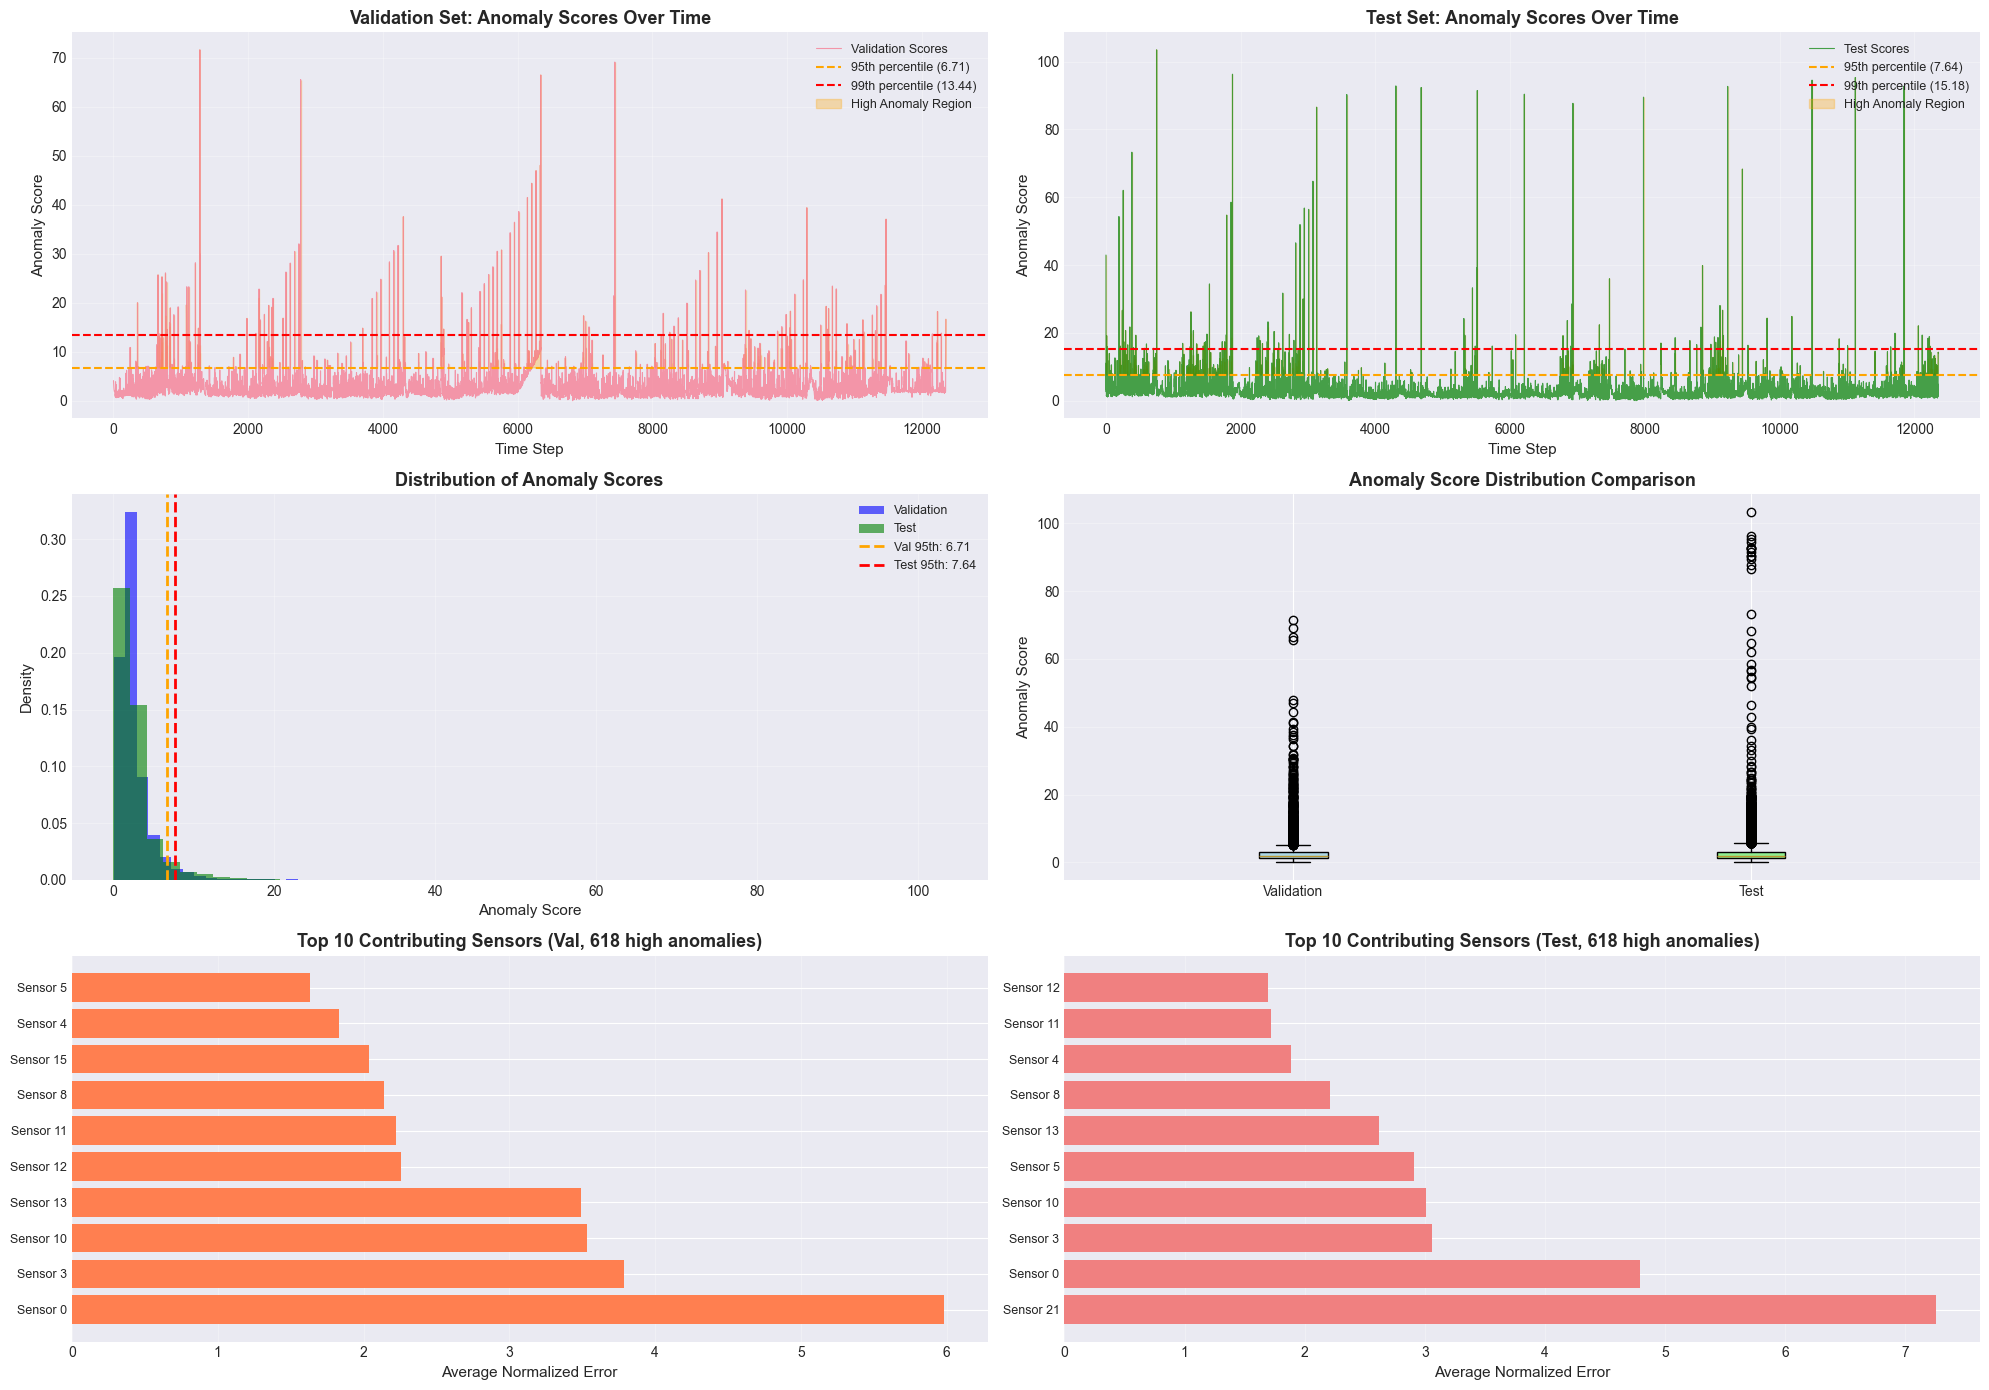

ANOMALY SCORE SUMMARY STATISTICS

Validation Set:
  Mean: 2.6673
  Median: 1.9473
  Std: 2.9708
  Min: 0.0135
  Max: 71.5623
  95th percentile: 6.7088
  99th percentile: 13.4436
  High anomalies (>= 95th percentile): 618 (5.00%)

Test Set:
  Mean: 2.9169
  Median: 1.9857
  Std: 4.3554
  Min: 0.0102
  Max: 103.4771
  95th percentile: 7.6381
  99th percentile: 15.1802
  High anomalies (>= 95th percentile): 618 (5.00%)


In [ ]:
# Visualize anomaly scores
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig = plt.figure(figsize=(20, 14))

# 1. Time series of anomaly scores (Validation)
ax1 = plt.subplot(3, 2, 1)
ax1.plot(val_scores, alpha=0.7, linewidth=0.8, label='Validation Scores')
# Highlight high anomaly regions
threshold_95 = np.percentile(val_scores, 95)
threshold_99 = np.percentile(val_scores, 99)
ax1.axhline(y=threshold_95, color='orange', linestyle='--', linewidth=1.5, label=f'95th percentile ({threshold_95:.2f})')
ax1.axhline(y=threshold_99, color='red', linestyle='--', linewidth=1.5, label=f'99th percentile ({threshold_99:.2f})')
ax1.fill_between(range(len(val_scores)), val_scores, threshold_95, where=(val_scores >= threshold_95), 
                 alpha=0.3, color='orange', label='High Anomaly Region')
ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Anomaly Score', fontsize=11)
ax1.set_title('Validation Set: Anomaly Scores Over Time', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Time series of anomaly scores (Test)
ax2 = plt.subplot(3, 2, 2)
ax2.plot(test_scores, alpha=0.7, linewidth=0.8, label='Test Scores', color='green')
# Highlight high anomaly regions
threshold_95_test = np.percentile(test_scores, 95)
threshold_99_test = np.percentile(test_scores, 99)
ax2.axhline(y=threshold_95_test, color='orange', linestyle='--', linewidth=1.5, label=f'95th percentile ({threshold_95_test:.2f})')
ax2.axhline(y=threshold_99_test, color='red', linestyle='--', linewidth=1.5, label=f'99th percentile ({threshold_99_test:.2f})')
ax2.fill_between(range(len(test_scores)), test_scores, threshold_95_test, where=(test_scores >= threshold_95_test), 
                 alpha=0.3, color='orange', label='High Anomaly Region')
ax2.set_xlabel('Time Step', fontsize=11)
ax2.set_ylabel('Anomaly Score', fontsize=11)
ax2.set_title('Test Set: Anomaly Scores Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Distribution of anomaly scores
ax3 = plt.subplot(3, 2, 3)
ax3.hist(val_scores, bins=50, alpha=0.6, label='Validation', density=True, color='blue')
ax3.hist(test_scores, bins=50, alpha=0.6, label='Test', density=True, color='green')
ax3.axvline(x=threshold_95, color='orange', linestyle='--', linewidth=2, label=f'Val 95th: {threshold_95:.2f}')
ax3.axvline(x=threshold_95_test, color='red', linestyle='--', linewidth=2, label=f'Test 95th: {threshold_95_test:.2f}')
ax3.set_xlabel('Anomaly Score', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Distribution of Anomaly Scores', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Box plot comparison
ax4 = plt.subplot(3, 2, 4)
box_data = [val_scores, test_scores]
bp = ax4.boxplot(box_data, labels=['Validation', 'Test'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
ax4.set_ylabel('Anomaly Score', fontsize=11)
ax4.set_title('Anomaly Score Distribution Comparison', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Top contributing sensors for high anomalies (Validation)
ax5 = plt.subplot(3, 2, 5)
high_anomaly_indices = np.where(val_scores >= threshold_95)[0]
if len(high_anomaly_indices) > 0:
    high_anomaly_sensor_scores = val_sensor_scores[high_anomaly_indices]
    sensor_contributions = np.mean(np.abs(high_anomaly_sensor_scores), axis=0)
    top_sensors = np.argsort(sensor_contributions)[-10:][::-1]
    
    y_pos = np.arange(len(top_sensors))
    ax5.barh(y_pos, sensor_contributions[top_sensors], color='coral')
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels([f'Sensor {i}' for i in top_sensors], fontsize=9)
    ax5.set_xlabel('Average Normalized Error', fontsize=11)
    ax5.set_title(f'Top 10 Contributing Sensors (Val, {len(high_anomaly_indices)} high anomalies)', 
                  fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='x')
else:
    ax5.text(0.5, 0.5, 'No high anomalies found', ha='center', va='center', fontsize=12)
    ax5.set_title('Top Contributing Sensors (Validation)', fontsize=13, fontweight='bold')

# 6. Top contributing sensors for high anomalies (Test)
ax6 = plt.subplot(3, 2, 6)
high_anomaly_indices_test = np.where(test_scores >= threshold_95_test)[0]
if len(high_anomaly_indices_test) > 0:
    high_anomaly_sensor_scores_test = test_sensor_scores[high_anomaly_indices_test]
    sensor_contributions_test = np.mean(np.abs(high_anomaly_sensor_scores_test), axis=0)
    top_sensors_test = np.argsort(sensor_contributions_test)[-10:][::-1]
    
    y_pos_test = np.arange(len(top_sensors_test))
    ax6.barh(y_pos_test, sensor_contributions_test[top_sensors_test], color='lightcoral')
    ax6.set_yticks(y_pos_test)
    ax6.set_yticklabels([f'Sensor {i}' for i in top_sensors_test], fontsize=9)
    ax6.set_xlabel('Average Normalized Error', fontsize=11)
    ax6.set_title(f'Top 10 Contributing Sensors (Test, {len(high_anomaly_indices_test)} high anomalies)', 
                  fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')
else:
    ax6.text(0.5, 0.5, 'No high anomalies found', ha='center', va='center', fontsize=12)
    ax6.set_title('Top Contributing Sensors (Test)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*70)
print("ANOMALY SCORE SUMMARY STATISTICS")
print("="*70)
print(f"\nValidation Set:")
print(f"  Mean: {np.mean(val_scores):.4f}")
print(f"  Median: {np.median(val_scores):.4f}")
print(f"  Std: {np.std(val_scores):.4f}")
print(f"  Min: {np.min(val_scores):.4f}")
print(f"  Max: {np.max(val_scores):.4f}")
print(f"  95th percentile: {threshold_95:.4f}")
print(f"  99th percentile: {threshold_99:.4f}")
print(f"  High anomalies (>= 95th percentile): {len(high_anomaly_indices)} ({100*len(high_anomaly_indices)/len(val_scores):.2f}%)")

print(f"\nTest Set:")
print(f"  Mean: {np.mean(test_scores):.4f}")
print(f"  Median: {np.median(test_scores):.4f}")
print(f"  Std: {np.std(test_scores):.4f}")
print(f"  Min: {np.min(test_scores):.4f}")
print(f"  Max: {np.max(test_scores):.4f}")
print(f"  95th percentile: {threshold_95_test:.4f}")
print(f"  99th percentile: {threshold_99_test:.4f}")
print(f"  High anomalies (>= 95th percentile): {len(high_anomaly_indices_test)} ({100*len(high_anomaly_indices_test)/len(test_scores):.2f}%)")
print("="*70)


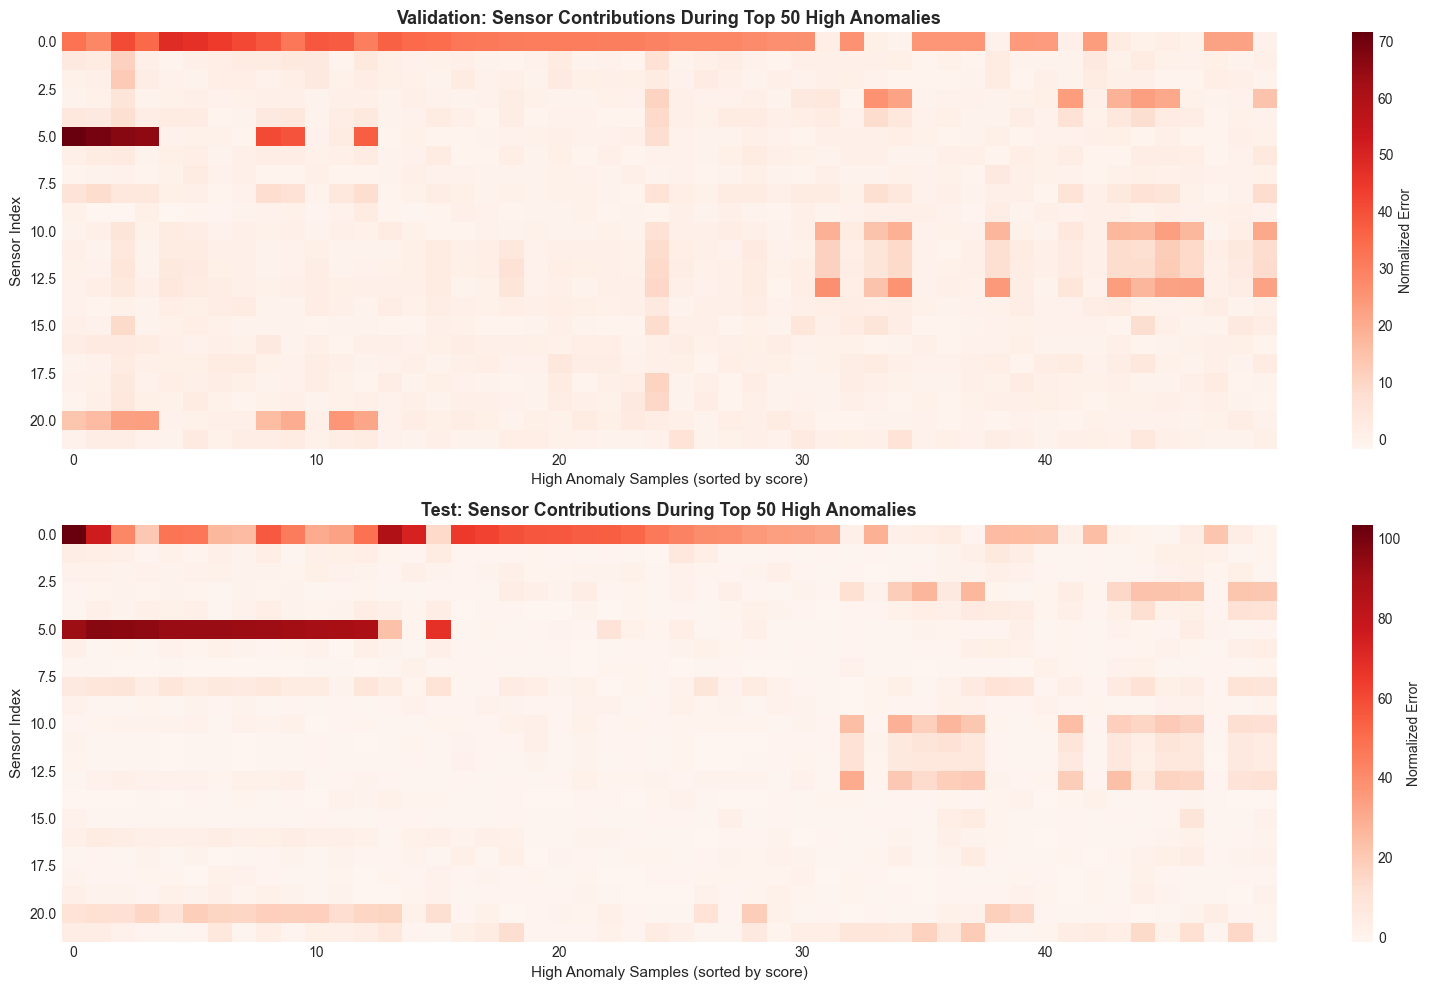

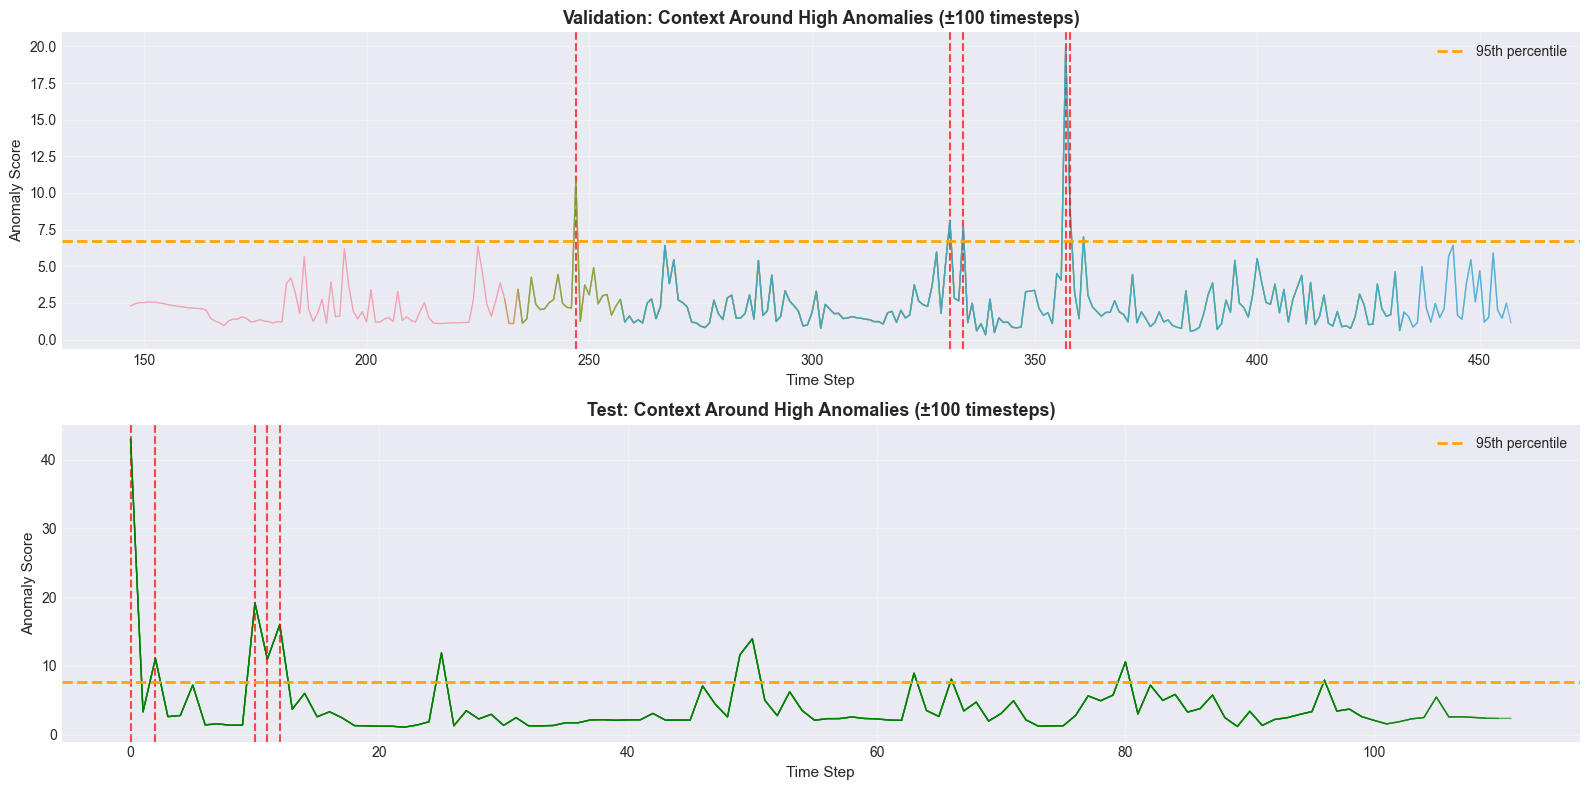

In [129]:
# Additional visualizations: Heatmap of sensor contributions during high anomalies
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Validation set heatmap
if len(high_anomaly_indices) > 0:
    # Get top 50 high anomaly samples for visualization
    top_anomalies_val = high_anomaly_indices[np.argsort(val_scores[high_anomaly_indices])[-50:][::-1]]
    heatmap_data_val = val_sensor_scores[top_anomalies_val].T
    
    im1 = axes[0].imshow(heatmap_data_val, aspect='auto', cmap='Reds', interpolation='nearest')
    axes[0].set_xlabel('High Anomaly Samples (sorted by score)', fontsize=11)
    axes[0].set_ylabel('Sensor Index', fontsize=11)
    axes[0].set_title('Validation: Sensor Contributions During Top 50 High Anomalies', fontsize=13, fontweight='bold')
    plt.colorbar(im1, ax=axes[0], label='Normalized Error')
    axes[0].grid(False)
else:
    axes[0].text(0.5, 0.5, 'No high anomalies found in validation set', 
                ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title('Validation: Sensor Contributions During High Anomalies', fontsize=13, fontweight='bold')

# Test set heatmap
if len(high_anomaly_indices_test) > 0:
    # Get top 50 high anomaly samples for visualization
    top_anomalies_test = high_anomaly_indices_test[np.argsort(test_scores[high_anomaly_indices_test])[-50:][::-1]]
    heatmap_data_test = test_sensor_scores[top_anomalies_test].T
    
    im2 = axes[1].imshow(heatmap_data_test, aspect='auto', cmap='Reds', interpolation='nearest')
    axes[1].set_xlabel('High Anomaly Samples (sorted by score)', fontsize=11)
    axes[1].set_ylabel('Sensor Index', fontsize=11)
    axes[1].set_title('Test: Sensor Contributions During Top 50 High Anomalies', fontsize=13, fontweight='bold')
    plt.colorbar(im2, ax=axes[1], label='Normalized Error')
    axes[1].grid(False)
else:
    axes[1].text(0.5, 0.5, 'No high anomalies found in test set', 
                ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title('Test: Sensor Contributions During High Anomalies', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Zoomed-in view of anomaly scores around high anomaly regions
if len(high_anomaly_indices) > 0 or len(high_anomaly_indices_test) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    
    # Validation: Show context around high anomalies
    if len(high_anomaly_indices) > 0:
        window_size_viz = 100
        for idx in high_anomaly_indices[:5]:  # Show first 5 high anomalies
            start = max(0, idx - window_size_viz)
            end = min(len(val_scores), idx + window_size_viz)
            axes[0].plot(range(start, end), val_scores[start:end], alpha=0.6, linewidth=1)
            axes[0].axvline(x=idx, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].axhline(y=threshold_95, color='orange', linestyle='--', linewidth=2, label=f'95th percentile')
        axes[0].set_xlabel('Time Step', fontsize=11)
        axes[0].set_ylabel('Anomaly Score', fontsize=11)
        axes[0].set_title('Validation: Context Around High Anomalies (±100 timesteps)', fontsize=13, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Test: Show context around high anomalies
    if len(high_anomaly_indices_test) > 0:
        window_size_viz = 100
        for idx in high_anomaly_indices_test[:5]:  # Show first 5 high anomalies
            start = max(0, idx - window_size_viz)
            end = min(len(test_scores), idx + window_size_viz)
            axes[1].plot(range(start, end), test_scores[start:end], alpha=0.6, linewidth=1, color='green')
            axes[1].axvline(x=idx, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[1].axhline(y=threshold_95_test, color='orange', linestyle='--', linewidth=2, label=f'95th percentile')
        axes[1].set_xlabel('Time Step', fontsize=11)
        axes[1].set_ylabel('Anomaly Score', fontsize=11)
        axes[1].set_title('Test: Context Around High Anomalies (±100 timesteps)', fontsize=13, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_28771/578811981.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([val_scores, test_scores], positions=[1, 2], widths=0.3,


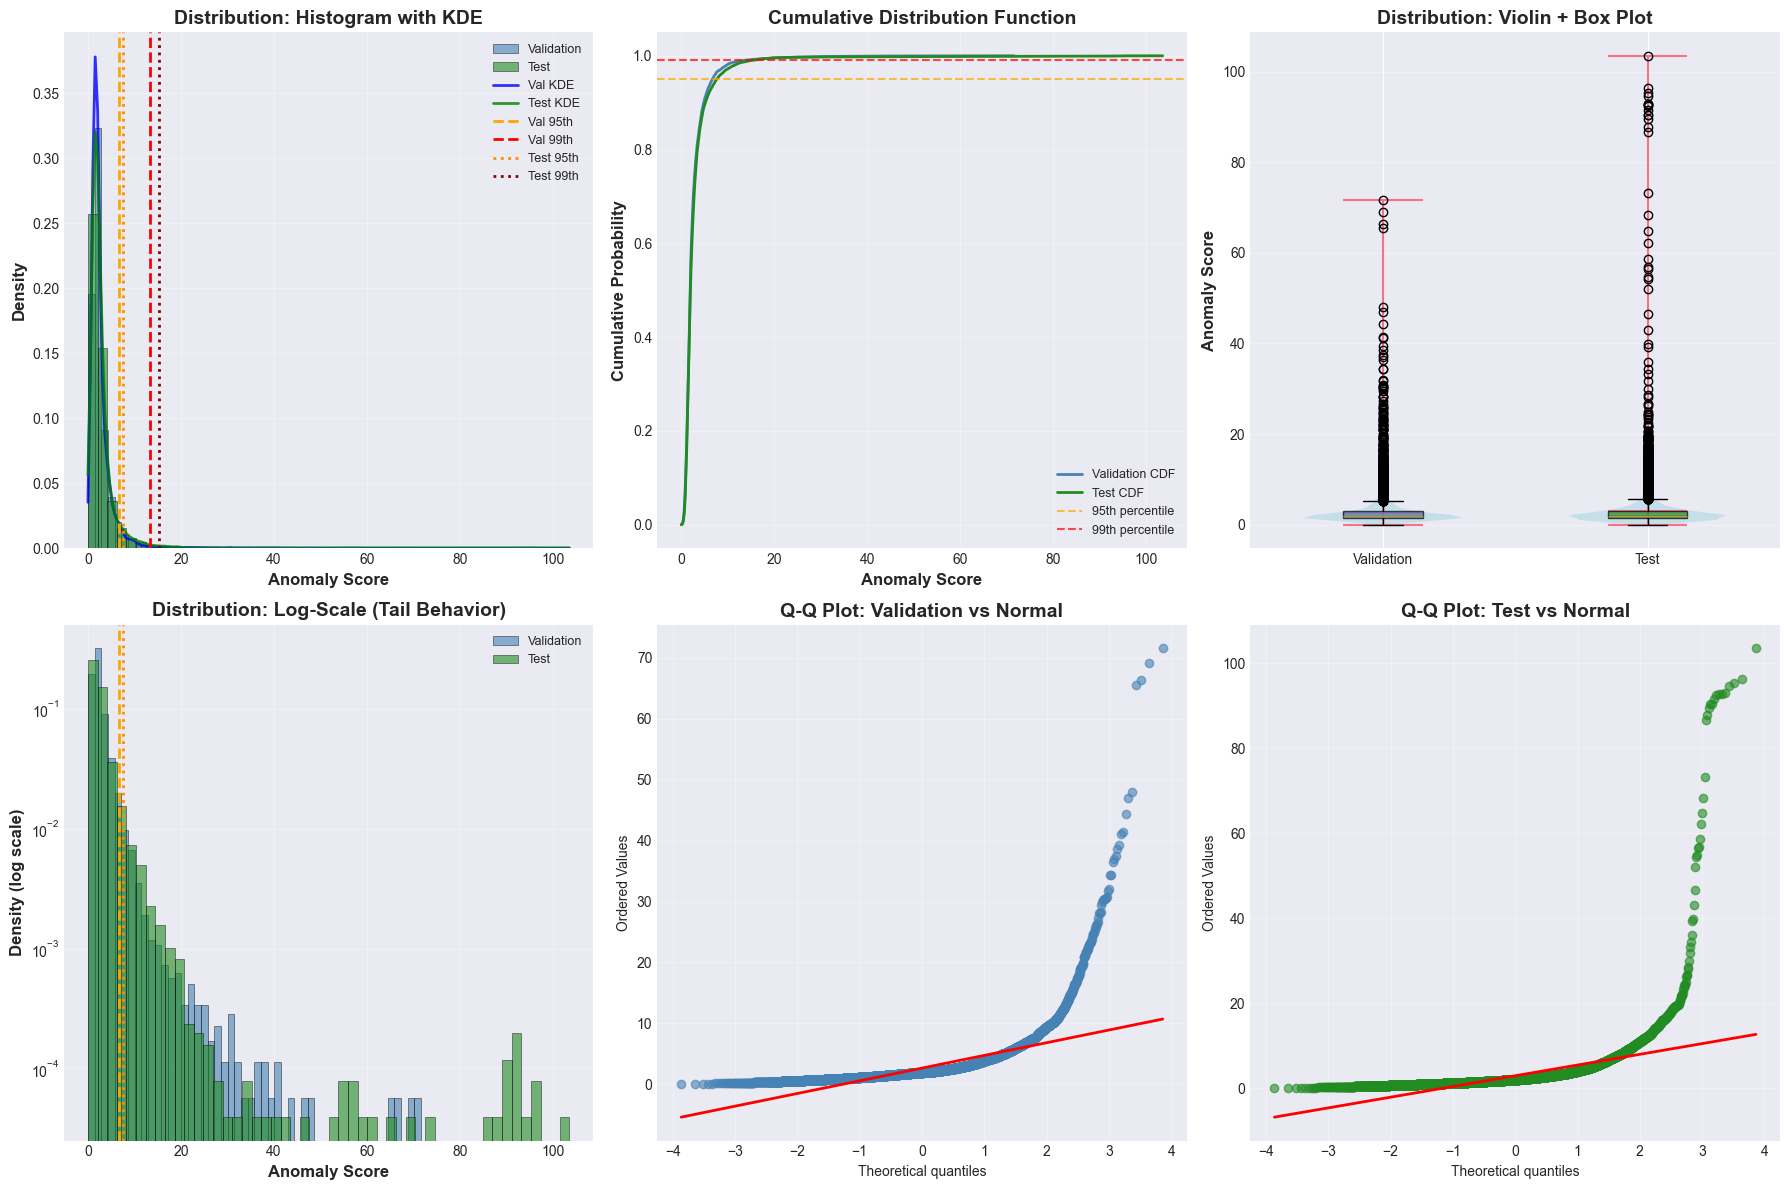


DETAILED DISTRIBUTION STATISTICS
         Metric Validation     Test
          Count      12356    12357
           Mean     2.6673   2.9169
         Median     1.9473   1.9857
        Std Dev     2.9708   4.3554
            Min     0.0135   0.0102
            Max    71.5623 103.4771
25th Percentile     1.3713   1.3987
75th Percentile     2.9308   3.0877
90th Percentile     4.8356   5.1966
95th Percentile     6.7088   7.6381
99th Percentile    13.4436  15.1802
       Skewness     8.0722  12.8580
       Kurtosis   117.1864 234.5455

INTERPRETATION:
• Skewness: Positive values indicate right-skewed distribution (tail on the right)
  - Validation skewness: 8.0722
  - Test skewness: 12.8580
• Kurtosis: Values > 3 indicate heavy tails (more outliers than normal distribution)
  - Validation kurtosis: 117.1864
  - Test kurtosis: 234.5455
• High anomaly rate (>= 95th percentile):
  - Validation: 618 samples (5.00%)
  - Test: 618 samples (5.00%)


In [130]:
# Focused Distribution Analysis of Anomaly Scores
from scipy import stats

fig = plt.figure(figsize=(18, 12))

# 1. Histogram with KDE overlay
ax1 = plt.subplot(2, 3, 1)
ax1.hist(val_scores, bins=50, alpha=0.6, label='Validation', density=True, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.hist(test_scores, bins=50, alpha=0.6, label='Test', density=True, color='forestgreen', edgecolor='black', linewidth=0.5)

# Add KDE curves
try:
    from scipy.stats import gaussian_kde
    kde_val = gaussian_kde(val_scores)
    kde_test = gaussian_kde(test_scores)
    x_range = np.linspace(min(val_scores.min(), test_scores.min()), 
                         max(val_scores.max(), test_scores.max()), 200)
    ax1.plot(x_range, kde_val(x_range), 'b-', linewidth=2, label='Val KDE', alpha=0.8)
    ax1.plot(x_range, kde_test(x_range), 'g-', linewidth=2, label='Test KDE', alpha=0.8)
except:
    pass

# Add percentile lines
ax1.axvline(x=np.percentile(val_scores, 95), color='orange', linestyle='--', linewidth=2, label='Val 95th')
ax1.axvline(x=np.percentile(val_scores, 99), color='red', linestyle='--', linewidth=2, label='Val 99th')
ax1.axvline(x=np.percentile(test_scores, 95), color='darkorange', linestyle=':', linewidth=2, label='Test 95th')
ax1.axvline(x=np.percentile(test_scores, 99), color='darkred', linestyle=':', linewidth=2, label='Test 99th')

ax1.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution: Histogram with KDE', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Cumulative Distribution Function (CDF)
ax2 = plt.subplot(2, 3, 2)
sorted_val = np.sort(val_scores)
sorted_test = np.sort(test_scores)
y_val = np.arange(1, len(sorted_val) + 1) / len(sorted_val)
y_test = np.arange(1, len(sorted_test) + 1) / len(sorted_test)

ax2.plot(sorted_val, y_val, label='Validation CDF', linewidth=2, color='steelblue')
ax2.plot(sorted_test, y_test, label='Test CDF', linewidth=2, color='forestgreen')
ax2.axhline(y=0.95, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='95th percentile')
ax2.axhline(y=0.99, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='99th percentile')
ax2.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Box plot with violin plot overlay
ax3 = plt.subplot(2, 3, 3)
parts = ax3.violinplot([val_scores, test_scores], positions=[1, 2], widths=0.6, 
                       showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.6)

bp = ax3.boxplot([val_scores, test_scores], positions=[1, 2], widths=0.3, 
                 patch_artist=True, labels=['Validation', 'Test'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('forestgreen')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

ax3.set_ylabel('Anomaly Score', fontsize=12, fontweight='bold')
ax3.set_title('Distribution: Violin + Box Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Log-scale histogram (to see tail behavior)
ax4 = plt.subplot(2, 3, 4)
ax4.hist(val_scores, bins=50, alpha=0.6, label='Validation', density=True, color='steelblue', edgecolor='black', linewidth=0.5)
ax4.hist(test_scores, bins=50, alpha=0.6, label='Test', density=True, color='forestgreen', edgecolor='black', linewidth=0.5)
ax4.set_yscale('log')
ax4.axvline(x=np.percentile(val_scores, 95), color='orange', linestyle='--', linewidth=2)
ax4.axvline(x=np.percentile(test_scores, 95), color='darkorange', linestyle=':', linewidth=2)
ax4.set_xlabel('Anomaly Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Density (log scale)', fontsize=12, fontweight='bold')
ax4.set_title('Distribution: Log-Scale (Tail Behavior)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Q-Q plot (checking for normality)
ax5 = plt.subplot(2, 3, 5)
stats.probplot(val_scores, dist="norm", plot=ax5)
ax5.get_lines()[0].set_color('steelblue')
ax5.get_lines()[0].set_markerfacecolor('steelblue')
ax5.get_lines()[0].set_alpha(0.6)
ax5.get_lines()[1].set_color('red')
ax5.get_lines()[1].set_linewidth(2)
ax5.set_title('Q-Q Plot: Validation vs Normal', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Q-Q plot for test set
ax6 = plt.subplot(2, 3, 6)
stats.probplot(test_scores, dist="norm", plot=ax6)
ax6.get_lines()[0].set_color('forestgreen')
ax6.get_lines()[0].set_markerfacecolor('forestgreen')
ax6.get_lines()[0].set_alpha(0.6)
ax6.get_lines()[1].set_color('red')
ax6.get_lines()[1].set_linewidth(2)
ax6.set_title('Q-Q Plot: Test vs Normal', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed statistics table
print("\n" + "="*80)
print("DETAILED DISTRIBUTION STATISTICS")
print("="*80)

stats_data = {
    'Metric': ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max', 
               '25th Percentile', '75th Percentile', '90th Percentile', 
               '95th Percentile', '99th Percentile', 'Skewness', 'Kurtosis'],
    'Validation': [
        len(val_scores),
        f"{np.mean(val_scores):.4f}",
        f"{np.median(val_scores):.4f}",
        f"{np.std(val_scores):.4f}",
        f"{np.min(val_scores):.4f}",
        f"{np.max(val_scores):.4f}",
        f"{np.percentile(val_scores, 25):.4f}",
        f"{np.percentile(val_scores, 75):.4f}",
        f"{np.percentile(val_scores, 90):.4f}",
        f"{np.percentile(val_scores, 95):.4f}",
        f"{np.percentile(val_scores, 99):.4f}",
        f"{stats.skew(val_scores):.4f}",
        f"{stats.kurtosis(val_scores):.4f}"
    ],
    'Test': [
        len(test_scores),
        f"{np.mean(test_scores):.4f}",
        f"{np.median(test_scores):.4f}",
        f"{np.std(test_scores):.4f}",
        f"{np.min(test_scores):.4f}",
        f"{np.max(test_scores):.4f}",
        f"{np.percentile(test_scores, 25):.4f}",
        f"{np.percentile(test_scores, 75):.4f}",
        f"{np.percentile(test_scores, 90):.4f}",
        f"{np.percentile(test_scores, 95):.4f}",
        f"{np.percentile(test_scores, 99):.4f}",
        f"{stats.skew(test_scores):.4f}",
        f"{stats.kurtosis(test_scores):.4f}"
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
print("="*80)

# Interpretation
print("\nINTERPRETATION:")
print(f"• Skewness: Positive values indicate right-skewed distribution (tail on the right)")
print(f"  - Validation skewness: {stats.skew(val_scores):.4f}")
print(f"  - Test skewness: {stats.skew(test_scores):.4f}")
print(f"• Kurtosis: Values > 3 indicate heavy tails (more outliers than normal distribution)")
print(f"  - Validation kurtosis: {stats.kurtosis(val_scores):.4f}")
print(f"  - Test kurtosis: {stats.kurtosis(test_scores):.4f}")
print(f"• High anomaly rate (>= 95th percentile):")
print(f"  - Validation: {len(high_anomaly_indices)} samples ({100*len(high_anomaly_indices)/len(val_scores):.2f}%)")
print(f"  - Test: {len(high_anomaly_indices_test)} samples ({100*len(high_anomaly_indices_test)/len(test_scores):.2f}%)")
print("="*80)
